In [1]:
# Setup and Load Data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean Total Charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop Customer ID
df.drop('customerID', axis=1, inplace=True)

# Separate Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset successfully loaded.")

Dataset successfully loaded.


/tmp/ipykernel_5256/2324992087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#3b528b', '#21918c'])


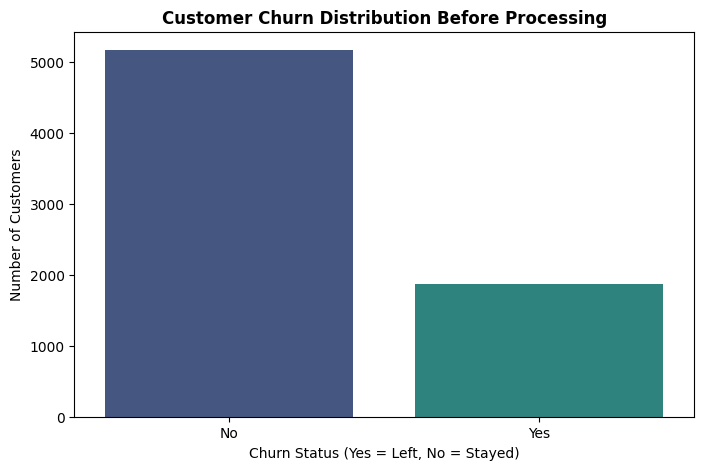

In [2]:
# Visualize Original Churn Data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', palette=['#3b528b', '#21918c'])
plt.title('Customer Churn Distribution Before Processing', fontweight='bold')
plt.xlabel('Churn Status (Yes = Left, No = Stayed)')
plt.ylabel('Number of Customers')
plt.show()

In [3]:
# Balance Churn Dataset
from sklearn.utils import resample

# Separate the classes
df_no = df[df.Churn == 'No']
df_yes = df[df.Churn == 'Yes']

# Undersample the majority class
df_no_downsampled = resample(df_no,
                             replace=False,    # sample without replacement
                             n_samples=len(df_yes), # match minority class count
                             random_state=42)  # for reproducible results

# Combine and Shuffle
df_balanced = pd.concat([df_no_downsampled, df_yes])
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Update Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset balanced and re-split.")

Dataset balanced and re-split.


/tmp/ipykernel_5256/2420540617.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#3b528b', '#21918c'])


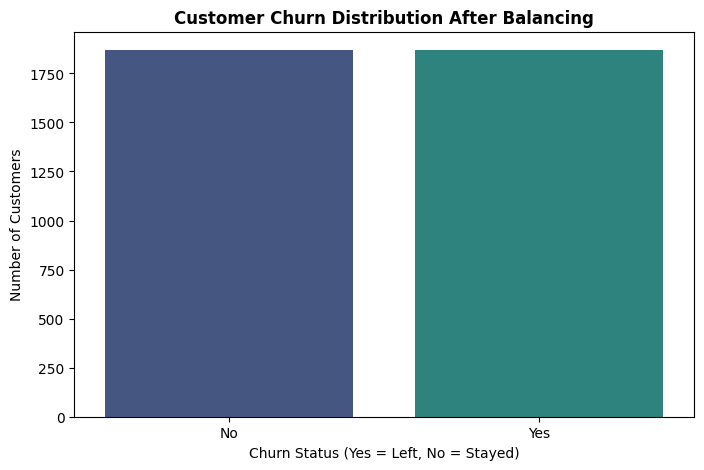

In [4]:
# Visualize Balanced Churn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', palette=['#3b528b', '#21918c'])
plt.title('Customer Churn Distribution After Balancing', fontweight='bold')
plt.xlabel('Churn Status (Yes = Left, No = Stayed)')
plt.ylabel('Number of Customers')
plt.show()

In [5]:
# Construct Machine Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Identify Column Types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Create Preprocessing Steps
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine All Preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create Final Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

print("Pipeline successfully constructed.")

Pipeline successfully constructed.


In [6]:
# Configure Hyperparameter Grid
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define Parameter Grid
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [0.1, 1.0, 10.0]
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [None, 5, 10]
    }
]

# Initialize Grid Search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Grid Search successfully configured.")

Grid Search successfully configured.


In [7]:
# Train and Select Model
import joblib
from sklearn.metrics import classification_report, accuracy_score

# Start Combined Training
print("Training Logistic Regression and Random Forest...")
grid_search.fit(X_train, y_train)

# Identify Best Estimator
best_model = grid_search.best_estimator_
print(f"\nWinning Model:\n{grid_search.best_params_['classifier']}")

# Predict on Test Set
y_pred = best_model.predict(X_test)

# Display Final Metrics
print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

# Save Final Pipeline
joblib.dump(best_model, "churn_prediction_model.joblib")
print("\nBest pipeline saved successfully.")

Training Logistic Regression and Random Forest...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Winning Model:
LogisticRegression(max_iter=1000, random_state=42)

Final Accuracy: 0.7687

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76       374
           1       0.76      0.79      0.77       374

    accuracy                           0.77       748
   macro avg       0.77      0.77      0.77       748
weighted avg       0.77      0.77      0.77       748


Best pipeline saved successfully.


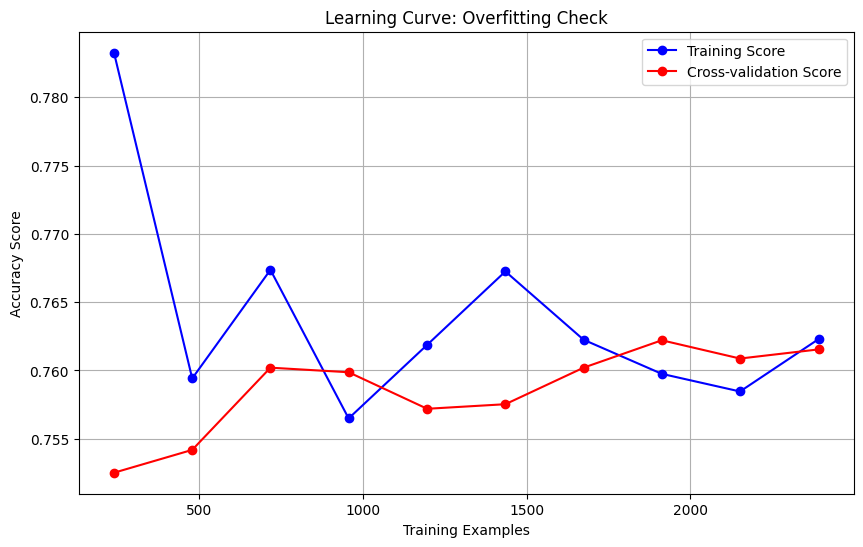

In [8]:
# Visualize Model Overfitting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="red", label="Cross-validation Score")
plt.title("Learning Curve: Overfitting Check")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

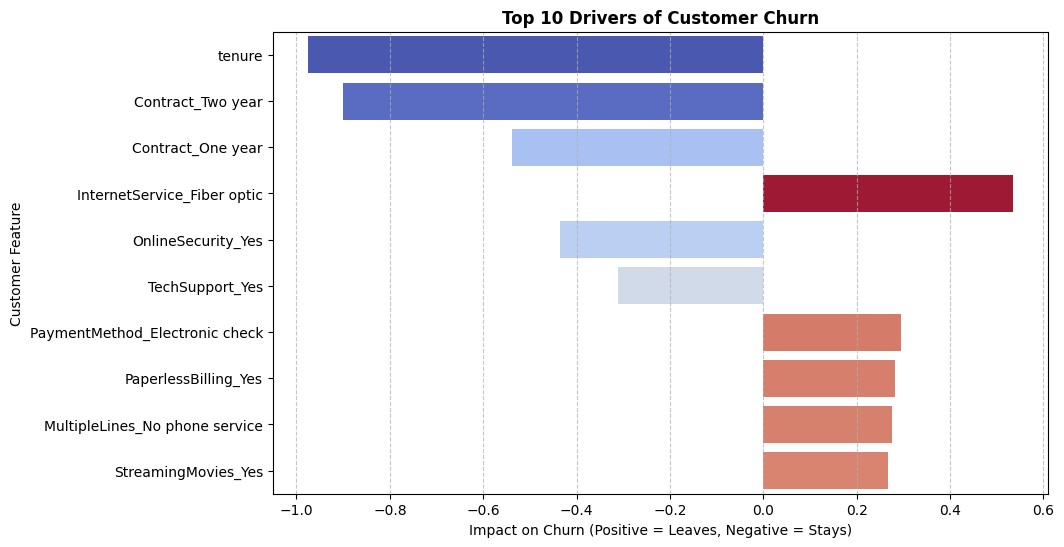

In [16]:
# Visualize Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the winning Logistic Regression model from our very first Grid Search
final_classifier = grid_search.best_estimator_.named_steps['classifier']
preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

# Extract feature names
cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features)

# Extract coefficients (importance)
importances = final_classifier.coef_[0]
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

# Sort by absolute value to find the strongest drivers
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False).head(10)

# Create the Graph
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Importance', palette='coolwarm', legend=False)
plt.title('Top 10 Drivers of Customer Churn', fontweight='bold')
plt.xlabel('Impact on Churn (Positive = Leaves, Negative = Stays)')
plt.ylabel('Customer Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# 1. Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
import joblib

# Define the exact parameters we want to test for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__max_iter': [1000]
}

print("Starting GridSearchCV for Hyperparameter Tuning...")
final_grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to our training data
final_grid_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters found: {final_grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {final_grid_search.best_score_:.4f}")

# Extract the absolute best model from the grid search
best_tuned_pipeline = final_grid_search.best_estimator_

# 2. Export the Complete Pipeline using joblib
print("\nExporting the complete tuned pipeline...")
joblib.dump(best_tuned_pipeline, 'final_tuned_churn_pipeline.joblib')
print("✅ Pipeline successfully saved as 'final_tuned_churn_pipeline.joblib'")

In [17]:
# Export Complete Pipeline
import joblib

# Export the winning model pipeline to a file
model_filename = 'churn_prediction_pipeline.joblib'
joblib.dump(best_model, model_filename)

print(f"✅ Complete pipeline successfully exported as '{model_filename}'")

✅ Complete pipeline successfully exported as 'churn_prediction_pipeline.joblib'
